In [9]:
from google.colab import files
uploaded = files.upload()


Saving dataset-tickets-multi-lang-4-20k.csv to dataset-tickets-multi-lang-4-20k (1).csv


In [10]:
from google.colab import files
uploaded = files.upload()

Saving aa_dataset-tickets-multi-lang-5-2-50-version.csv to aa_dataset-tickets-multi-lang-5-2-50-version (1).csv


In [11]:
import pandas as pd

df_v4 = pd.read_csv("dataset-tickets-multi-lang-4-20k.csv")
print("v4 shape:", df_v4.shape)
print("v4 columns:", df_v4.columns.tolist())

df_v5 = pd.read_csv("aa_dataset-tickets-multi-lang-5-2-50-version.csv")
print("\nv5 shape:", df_v5.shape)
print("v5 columns:", df_v5.columns.tolist())

print("\nSample row from v5:")
print(df_v5.head(2))

v4 shape: (20000, 15)
v4 columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

v5 shape: (28587, 16)
v5 columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

Sample row from v5:
                           subject  \
0  Wesentlicher Sicherheitsvorfall   
1               Account Disruption   

                                                body  \
0  Sehr geehrtes Support-Team,\n\nich möchte eine...   
1  Dear Customer Support Team,\n\nI am writing to...   

                                              answer      type  \
0  Vielen Dank für die Meldung des kritischen Sic...  Incident   
1  Thank you for reaching out, <name>. We are awa...  Incident   

               queue priority language  version     tag_1       tag_2  \
0  Technical Support     high       de       51  Security

Shape: (28587, 16)

Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

Sample row:
 subject                       Wesentlicher Sicherheitsvorfall
body        Sehr geehrtes Support-Team,\n\nich möchte eine...
answer      Vielen Dank für die Meldung des kritischen Sic...
type                                                 Incident
queue                                       Technical Support
priority                                                 high
language                                                   de
version                                                    51
tag_1                                                Security
tag_2                                                  Outage
tag_3                                              Disruption
tag_4                                             Data Breach
tag_5                                                     N

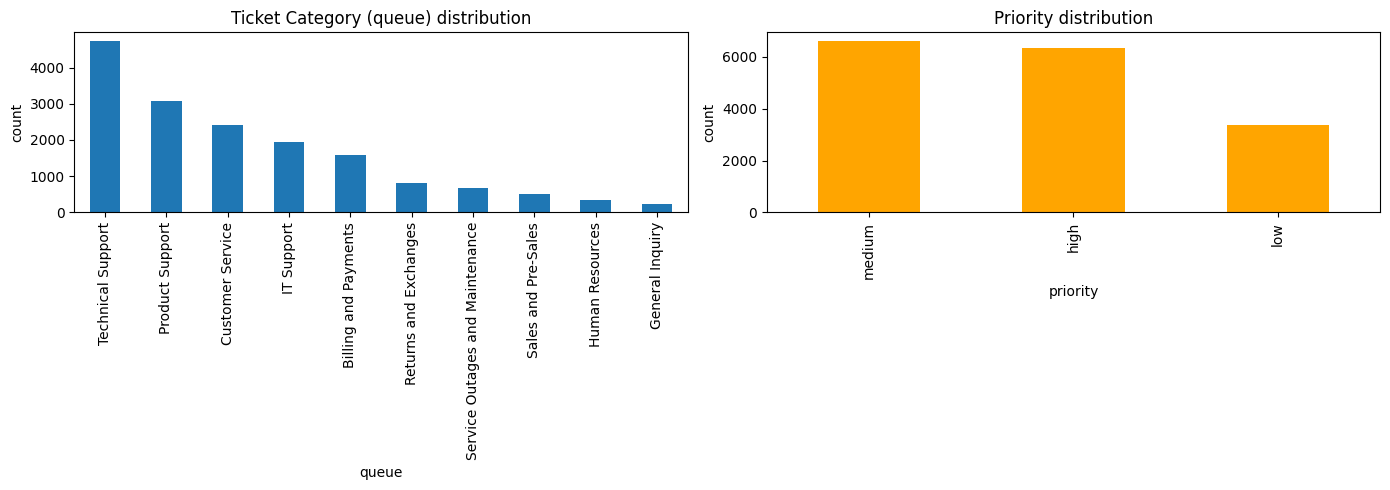

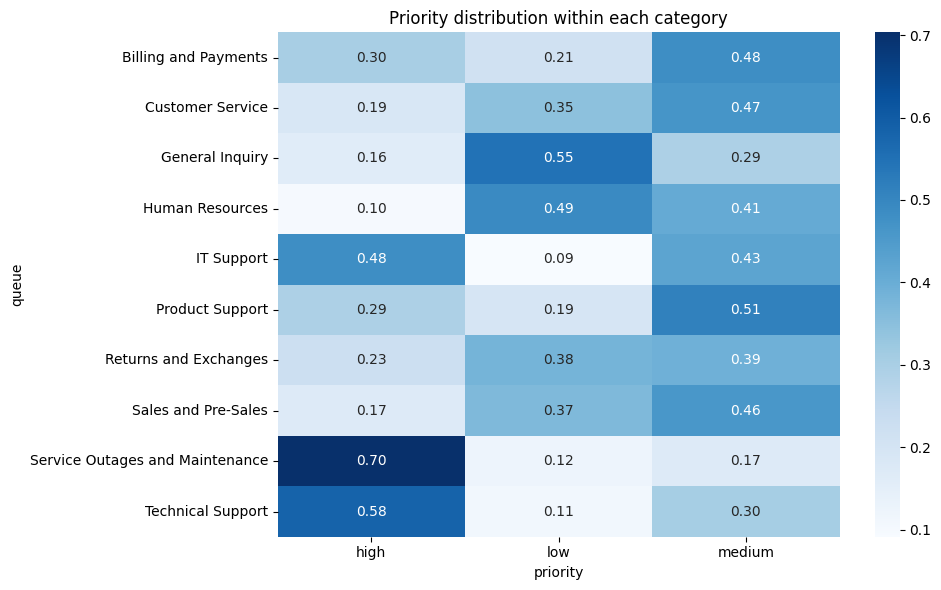


Text length (words) stats:
 count    16338.000000
mean        58.802607
std         26.889797
min          2.000000
25%         36.000000
50%         60.000000
75%         82.000000
max        172.000000
Name: text_len_words, dtype: float64


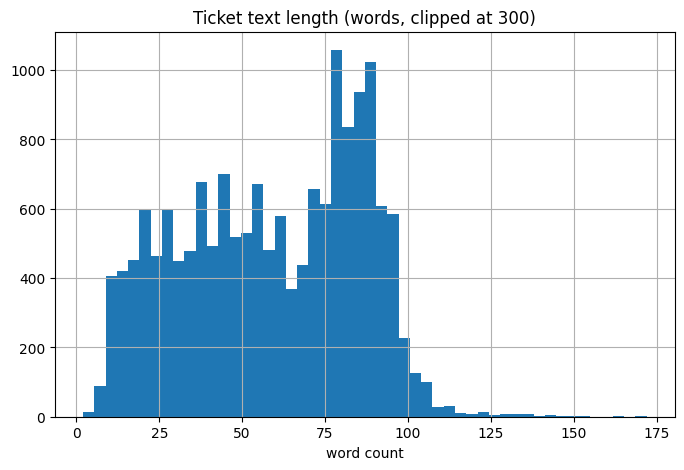


Estimated handle time stats:
 count    16338.000000
mean        29.173742
std         16.333418
min          4.500000
25%         16.600000
50%         25.100000
75%         38.900000
max        125.400000
Name: estimated_handle_time_min, dtype: float64

Unique queues (these become your 'required skill' labels):
['Technical Support' 'Returns and Exchanges' 'Billing and Payments'
 'Sales and Pre-Sales' 'Service Outages and Maintenance' 'Product Support'
 'IT Support' 'Customer Service' 'Human Resources' 'General Inquiry']

Saved cleaned dataset -> tickets_clean.csv
                                                text                  queue  \
1  Account Disruption. Dear Customer Support Team...      Technical Support   
2  Query About Smart Home System Integration Feat...  Returns and Exchanges   
3  Inquiry Regarding Invoice Details. Dear Custom...   Billing and Payments   
4  Question About Marketing Agency Software Compa...    Sales and Pre-Sales   
5  Feature Query. Dear Customer S

In [12]:

# STAGE 1: Data Loading & EDA


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
df = pd.read_csv("aa_dataset-tickets-multi-lang-5-2-50-version.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample row:\n", df.iloc[0])
print("\nqueue values:\n", df["queue"].value_counts())
print("\npriority values:\n", df["priority"].value_counts())
print("\ntype values:\n", df["type"].value_counts())

# ------------------------------------------------------------
# 2. Basic cleaning / filtering
# ------------------------------------------------------------
if "language" in df.columns:
    print("\nLanguage distribution:\n", df["language"].value_counts())
    df = df[df["language"] == "en"].copy()

df["text"] = (df["subject"].fillna("") + ". " + df["body"].fillna("")).str.strip()

df = df.dropna(subset=["text", "queue", "priority"])
df = df[df["text"].str.len() > 10]

print("\nShape after cleaning:", df.shape)

# ------------------------------------------------------------
# 3. EDA — distributions
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["queue"].value_counts().plot(kind="bar", ax=axes[0], title="Ticket Category (queue) distribution")
axes[0].set_ylabel("count")

df["priority"].value_counts().plot(kind="bar", ax=axes[1], title="Priority distribution", color="orange")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)
plt.show()

ct = pd.crosstab(df["queue"], df["priority"], normalize="index")
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Priority distribution within each category")
plt.tight_layout()
plt.savefig("eda_priority_by_category.png", dpi=150)
plt.show()

df["text_len_words"] = df["text"].str.split().str.len()
print("\nText length (words) stats:\n", df["text_len_words"].describe())

plt.figure(figsize=(8, 5))
df["text_len_words"].clip(upper=300).hist(bins=50)
plt.title("Ticket text length (words, clipped at 300)")
plt.xlabel("word count")
plt.savefig("eda_text_length.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# 4. Derive what the dataset DOESN'T give us (handling time proxy)
# ------------------------------------------------------------
priority_base_minutes = {
    "low": 15,
    "medium": 25,
    "high": 40,
    "critical": 60,
}
df["priority_norm"] = df["priority"].str.lower().str.strip()
df["base_handle_time"] = df["priority_norm"].map(priority_base_minutes).fillna(25)

np.random.seed(42)
length_factor = (df["text_len_words"] / df["text_len_words"].median()).clip(0.5, 3.0)
noise = np.random.normal(1.0, 0.15, size=len(df)).clip(0.6, 1.6)
df["estimated_handle_time_min"] = (df["base_handle_time"] * length_factor * noise).round(1)

print("\nEstimated handle time stats:\n", df["estimated_handle_time_min"].describe())

print("\nUnique queues (these become your 'required skill' labels):")
print(df["queue"].unique())

# ------------------------------------------------------------
# 5. Save cleaned dataset for Stage 2
# ------------------------------------------------------------
df_out = df[[
    "text", "queue", "priority_norm", "text_len_words", "estimated_handle_time_min"
]].rename(columns={"priority_norm": "priority"})

df_out.to_csv("tickets_clean.csv", index=False)
print("\nSaved cleaned dataset -> tickets_clean.csv")
print(df_out.head())

In [13]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [14]:
import os

print(os.listdir())

['.config', 'final_queue_model', 'aa_dataset-tickets-multi-lang-5-2-50-version.csv', 'eda_text_length.png', 'queue_model', 'tickets_clean.csv', 'dataset-tickets-multi-lang-4-20k.csv', 'final_tokenizer', 'priority_model', 'final_priority_model', 'eda_distributions.png', 'eda_priority_by_category.png', 'dataset-tickets-multi-lang-4-20k (1).csv', 'test_predictions.csv', 'aa_dataset-tickets-multi-lang-5-2-50-version (1).csv', 'sample_data']


In [7]:

# STAGE 2: Fine-tune DistilBERT for category (queue) + priority


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ------------------------------------------------------------
# 1. Load cleaned data
# ------------------------------------------------------------
df = pd.read_csv("tickets_clean.csv")
print(df.shape)
print(df["queue"].value_counts())
print(df["priority"].value_counts())

# ------------------------------------------------------------
# 2. Encode labels
# ------------------------------------------------------------
queue_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

df["queue_label"] = queue_encoder.fit_transform(df["queue"])
df["priority_label"] = priority_encoder.fit_transform(df["priority"])

n_queue_classes = len(queue_encoder.classes_)
n_priority_classes = len(priority_encoder.classes_)
print("Queue classes:", queue_encoder.classes_)
print("Priority classes:", priority_encoder.classes_)

# ------------------------------------------------------------
# 3. Train/val/test split (stratified on queue)
# ------------------------------------------------------------
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["queue_label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["queue_label"], random_state=42
)
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

# ------------------------------------------------------------
# 4. Tokenizer + Dataset class
# ------------------------------------------------------------
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TicketDataset(Dataset):
    def __init__(self, texts, queue_labels, priority_labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.queue_labels = queue_labels.tolist()
        self.priority_labels = priority_labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.queue_labels[idx], dtype=torch.long)
        item["priority_labels"] = torch.tensor(self.priority_labels[idx], dtype=torch.long)
        return item

train_ds = TicketDataset(train_df["text"], train_df["queue_label"], train_df["priority_label"], tokenizer)
val_ds = TicketDataset(val_df["text"], val_df["queue_label"], val_df["priority_label"], tokenizer)
test_ds = TicketDataset(test_df["text"], test_df["queue_label"], test_df["priority_label"], tokenizer)

# ============================================================
# MODEL A: Category (queue) classifier
# ============================================================
model_queue = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=n_queue_classes
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

args_queue = TrainingArguments(
    output_dir="./queue_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer_queue = Trainer(
    model=model_queue,
    args=args_queue,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer_queue.train()

# Evaluate on test set
preds_queue = trainer_queue.predict(test_ds)
y_pred_queue = np.argmax(preds_queue.predictions, axis=1)
y_true_queue = test_df["queue_label"].values

print("\n=== QUEUE (category) classification report ===")
print(classification_report(y_true_queue, y_pred_queue, target_names=queue_encoder.classes_))

# ============================================================
# MODEL B: Priority classifier (separate head, same approach)
# ============================================================
class PriorityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_len, return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds_p = PriorityDataset(train_df["text"], train_df["priority_label"], tokenizer)
val_ds_p = PriorityDataset(val_df["text"], val_df["priority_label"], tokenizer)
test_ds_p = PriorityDataset(test_df["text"], test_df["priority_label"], tokenizer)

model_priority = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=n_priority_classes
)

args_priority = TrainingArguments(
    output_dir="./priority_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer_priority = Trainer(
    model=model_priority,
    args=args_priority,
    train_dataset=train_ds_p,
    eval_dataset=val_ds_p,
    compute_metrics=compute_metrics,
)

trainer_priority.train()

preds_priority = trainer_priority.predict(test_ds_p)
y_pred_priority = np.argmax(preds_priority.predictions, axis=1)
y_true_priority = test_df["priority_label"].values

print("\n=== PRIORITY classification report ===")
print(classification_report(y_true_priority, y_pred_priority, target_names=priority_encoder.classes_))

# ------------------------------------------------------------
# 5. Confidence scores (for calibration / OR layer input later)
# ------------------------------------------------------------
queue_probs = torch.softmax(torch.tensor(preds_queue.predictions), dim=1).numpy()
priority_probs = torch.softmax(torch.tensor(preds_priority.predictions), dim=1).numpy()

test_df = test_df.copy()
test_df["pred_queue"] = queue_encoder.inverse_transform(y_pred_queue)
test_df["pred_queue_confidence"] = queue_probs.max(axis=1)
test_df["pred_priority"] = priority_encoder.inverse_transform(y_pred_priority)
test_df["pred_priority_confidence"] = priority_probs.max(axis=1)

test_df.to_csv("test_predictions.csv", index=False)
print("\nSaved test_predictions.csv — this feeds into Stage 3 (the OR layer)")
print(test_df[["text", "queue", "pred_queue", "pred_queue_confidence",
                "priority", "pred_priority", "pred_priority_confidence"]].head())

# Save models for reuse
trainer_queue.save_model("./final_queue_model")
trainer_priority.save_model("./final_priority_model")
tokenizer.save_pretrained("./final_tokenizer")
print("\nModels saved.")

(16338, 5)
queue
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64
priority
medium    6618
high      6346
low       3374
Name: count, dtype: int64
Queue classes: ['Billing and Payments' 'Customer Service' 'General Inquiry'
 'Human Resources' 'IT Support' 'Product Support' 'Returns and Exchanges'
 'Sales and Pre-Sales' 'Service Outages and Maintenance'
 'Technical Support']
Priority classes: ['high' 'low' 'medium']
Train: 11436 Val: 2451 Test: 2451


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== PRIORITY classification report ===
              precision    recall  f1-score   support

        high       0.61      0.67      0.64       923
         low       0.50      0.30      0.37       500
      medium       0.55      0.61      0.58      1028

    accuracy                           0.57      2451
   macro avg       0.55      0.52      0.53      2451
weighted avg       0.56      0.57      0.56      2451


Saved test_predictions.csv — this feeds into Stage 3 (the OR layer)
                                                    text  \
3100   . Drafting a report on sporadic access problem...   
4023   Update on Digital Strategy. Customer Support h...   
2323   Problem with Investment Data Analytics Platfor...   
14670  Inquiries About Project Management SaaS Billin...   
7169   Support SaaS Platform Issue. Our system has be...   

                                 queue            pred_queue  \
3100   Service Outages and Maintenance       Product Support   
4023                 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Models saved.


In [ ]:
import pandas as pd

# Load the predictions, which represent the tickets to be assigned
tickets = pd.read_csv("test_predictions.csv")

print("Tickets DataFrame loaded:")
display(tickets.head())
print(f"Shape: {tickets.shape}")

In [18]:
from ortools.sat.python import cp_model

print("OR-Tools works!")

OR-Tools works!


In [16]:
!pip install -q --upgrade ortools protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


In [17]:
from ortools.sat.python import cp_model

In [19]:
print("assignments_df" in globals())

False


In [20]:
print("tickets" in globals())
print("model" in globals())
print("solver" in globals())
print("assignments" in globals())

False
False
False
False


In [59]:
print(status)

CpSolverStatus.INFEASIBLE


In [22]:
agents = {
    "A1": ["Technical Support", "IT Support"],
    "A2": ["Billing and Payments"],
    "A3": ["Customer Service"],
    "A4": ["Product Support"],
    "A5": ["Returns and Exchanges"],
    "A6": ["Sales and Pre-Sales"],
    "A7": ["Human Resources"],
    "A8": ["General Inquiry"],
    "A9": ["Service Outages and Maintenance"],
    "A10": ["Technical Support", "Product Support"]
}

In [34]:
from ortools.sat.python import cp_model
import pandas as pd

# Load the predictions, which represent the tickets to be assigned
tickets = pd.read_csv("test_predictions.csv")

# Create the CP-SAT model
model = cp_model.CpModel()

# Create the solver
solver = cp_model.CpSolver()

# Scaling factor for handle times, as CP-SAT works with integers
# estimated_handle_time_min is rounded to 1 decimal place, so multiply by 10
TIME_SCALE_FACTOR = 10

# Variables
# x[(ticket_id, agent_id)] is a boolean variable that is true if ticket 't' is assigned to agent 'a'.
x = {}
for t_idx in tickets.index:
    required_queue = tickets.loc[t_idx, "pred_queue"]
    for agent_name, agent_skills in agents.items():
        if required_queue in agent_skills:
            x[(t_idx, agent_name)] = model.NewBoolVar(f"ticket_{t_idx}_agent_{agent_name}")

# Constraints

# 1. Each ticket must be assigned to exactly one agent
for t_idx in tickets.index:
    # Collect all possible assignments for this ticket
    possible_assignments = []
    for agent_name, agent_skills in agents.items():
        required_queue = tickets.loc[t_idx, "pred_queue"]
        if required_queue in agent_skills:
            if (t_idx, agent_name) in x: # Check if the variable exists
                possible_assignments.append(x[(t_idx, agent_name)])

    # Ensure the ticket is assigned if there are any eligible agents
    if possible_assignments:
        model.Add(sum(possible_assignments) == 1)
    else:
        print(f"Warning: Ticket {t_idx} (Queue: {tickets.loc[t_idx, 'pred_queue']}) has no eligible agents.")
        # Optionally, handle unassignable tickets (e.g., assign to a 'fallback' agent, or just skip it for optimization)

# 2. Agent workload capacity constraint
# Assume a daily capacity of 8 hours (480 minutes) per agent, scaled by TIME_SCALE_FACTOR
AGENT_DAILY_CAPACITY_MIN_SCALED = 480 * TIME_SCALE_FACTOR

for agent_name in agents.keys():
    agent_total_handle_time = []
    for t_idx in tickets.index:
        if (t_idx, agent_name) in x: # Check if the variable exists
            # Scale handle time to an integer
            handle_time_scaled = int(tickets.loc[t_idx, "estimated_handle_time_min"] * TIME_SCALE_FACTOR)
            # Add (handle_time_scaled * x[(t_idx, agent_name)]) to the sum
            agent_total_handle_time.append(x[(t_idx, agent_name)] * handle_time_scaled)

    if agent_total_handle_time:
        model.Add(sum(agent_total_handle_time) <= AGENT_DAILY_CAPACITY_MIN_SCALED)

# Objective: Minimize total estimated handle time across all assignments
objective_terms = []
for t_idx in tickets.index:
    for agent_name, agent_skills in agents.items():
        required_queue = tickets.loc[t_idx, "pred_queue"]
        if required_queue in agent_skills:
            if (t_idx, agent_name) in x: # Check if the variable exists
                # Scale handle time to an integer for the objective function
                handle_time_scaled = int(tickets.loc[t_idx, "estimated_handle_time_min"] * TIME_SCALE_FACTOR)
                objective_terms.append(x[(t_idx, agent_name)] * handle_time_scaled)

if objective_terms:
    model.Minimize(sum(objective_terms))
else:
    print("Warning: No objective terms could be created. Model might be trivial or unsolvable.")

# Solve the model
print("Solving model...")
status = solver.Solve(model)
print("Model solving finished.")

Solving model...
Model solving finished.


In [35]:
print(f"Solver status: {solver.StatusName(status)}")

assignments = []
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print(f"Total estimated handle time: {solver.ObjectiveValue()} minutes")
    for t_idx in tickets.index:
        required_queue = tickets.loc[t_idx, "pred_queue"]
        for agent_name, agent_skills in agents.items():
            if required_queue in agent_skills and (t_idx, agent_name) in x: # Check if the variable exists
                if solver.Value(x[(t_idx, agent_name)]) == 1:
                    assignments.append({
                        "ticket_id": t_idx,
                        "queue": tickets.loc[t_idx, "pred_queue"],
                        "priority": tickets.loc[t_idx, "pred_priority"],
                        "agent": agent_name,
                        "handle_time": tickets.loc[t_idx, "estimated_handle_time_min"]
                    })

    assignments_df = pd.DataFrame(assignments)
    print("\nAssignments DataFrame created:")
    display(assignments_df.head())
    print(f"Shape: {assignments_df.shape}")
else:
    print("No optimal or feasible solution found.")
    assignments_df = pd.DataFrame(columns=["ticket_id", "queue", "priority", "agent", "handle_time"])

Solver status: INFEASIBLE
No optimal or feasible solution found.


In [36]:
print("x" in globals())

True


In [37]:
print("model" in globals())
print("solver" in globals())
print("x" in globals())
print("agents" in globals())

True
True
True
True


In [38]:
x = {}

for t in tickets.index:
    required_queue = tickets.loc[t, "pred_queue"]

    for a in agents:

        if required_queue in agents[a]:

            x[(t, a)] = model.NewBoolVar(
                f"ticket_{t}_agent_{a}"
            )

In [39]:
import pandas as pd

# Reload tickets DataFrame in case of kernel restart or variable clearance
tickets = pd.read_csv("test_predictions.csv")

assignments = []

for t in tickets.index:

    for a in agents:

        if (t, a) in x:

            if solver.Value(x[(t, a)]) == 1:

                assignments.append({
                    "ticket_id": t,
                    "queue": tickets.loc[t, "pred_queue"],
                    "priority": tickets.loc[t, "pred_priority"],
                    "agent": a,
                    "handle_time": tickets.loc[t, "estimated_handle_time_min"]
                })

assignments_df = pd.DataFrame(assignments)

print(assignments_df.head())
print(assignments_df.shape)

   ticket_id              queue priority agent  handle_time
0         18  Technical Support     high   A10         48.4
1         68  Technical Support     high   A10         21.1
2        174         IT Support   medium    A1         29.6
3        220  Technical Support     high   A10         60.2
4        267    Product Support      low   A10         19.2
(83, 5)


In [40]:
assignments_df.to_csv("optimized_assignments.csv", index=False)
print("Saved optimized_assignments.csv")

Saved optimized_assignments.csv


In [41]:
assignments_df["agent"].value_counts()

,count
agent,
A10,32
A1,25
A4,12
A2,7
A9,3
A3,2
A5,1
A6,1


In [42]:

# STAGE 4: Evaluation Metrics

import pandas as pd
import numpy as np

# Load optimized assignments
opt_df = assignments_df.copy()

# -----------------------------
# FIFO BASELINE
# -----------------------------
fifo_df = opt_df.copy()

fifo_df["fifo_wait_time"] = np.arange(len(fifo_df)) * 5

# -----------------------------
# OPTIMIZED
# -----------------------------
opt_df["optimized_wait_time"] = 0

agent_end_time = {}

for agent in opt_df["agent"].unique():
    agent_end_time[agent] = 0

for idx, row in opt_df.iterrows():

    agent = row["agent"]

    opt_df.loc[idx, "optimized_wait_time"] = agent_end_time[agent]

    agent_end_time[agent] += row["handle_time"]

# -----------------------------
# SLA Thresholds
# -----------------------------
sla_limit = {
    "high": 60,
    "medium": 240,
    "low": 480
}

fifo_df["sla_breach"] = fifo_df.apply(
    lambda r: r["fifo_wait_time"] > sla_limit[r["priority"]],
    axis=1
)

opt_df["sla_breach"] = opt_df.apply(
    lambda r: r["optimized_wait_time"] > sla_limit[r["priority"]],
    axis=1
)

# -----------------------------
# Metrics
# -----------------------------
fifo_avg_wait = fifo_df["fifo_wait_time"].mean()
opt_avg_wait = opt_df["optimized_wait_time"].mean()

fifo_breach = fifo_df["sla_breach"].sum()
opt_breach = opt_df["sla_breach"].sum()

improvement = (
    (fifo_avg_wait - opt_avg_wait)
    / fifo_avg_wait
) * 100

print("="*50)
print("FIFO Avg Wait Time:", round(fifo_avg_wait,2))
print("Optimized Avg Wait Time:", round(opt_avg_wait,2))
print("Improvement %:", round(improvement,2))

print("\nFIFO SLA Breaches:", fifo_breach)
print("Optimized SLA Breaches:", opt_breach)

# -----------------------------
# Agent Utilization
# -----------------------------
utilization = (
    opt_df.groupby("agent")["handle_time"]
    .sum()
    .sort_values(ascending=False)
)

print("\nAgent Utilization (minutes)")
print(utilization)

# -----------------------------
# Save Results
# -----------------------------
opt_df.to_csv("final_routing_results.csv", index=False)

print("\nSaved: final_routing_results.csv")

FIFO Avg Wait Time: 205.0
Optimized Avg Wait Time: 359.65
Improvement %: -75.44

FIFO SLA Breaches: 49
Optimized SLA Breaches: 53

Agent Utilization (minutes)
agent
A10    1045.2
A1      811.1
A4      319.9
A2      155.4
A3       69.7
A9       65.3
A5       62.0
A6       32.8
Name: handle_time, dtype: float64

Saved: final_routing_results.csv


/tmp/ipykernel_666/1556516899.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '48.4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  opt_df.loc[idx, "optimized_wait_time"] = agent_end_time[agent]


In [43]:
utilization = opt_df.groupby("agent")["handle_time"].sum()

print(utilization)
print("\nMax workload:", utilization.max())
print("Min workload:", utilization.min())
print("Std workload:", utilization.std())

agent
A1      811.1
A10    1045.2
A2      155.4
A3       69.7
A4      319.9
A5       62.0
A6       32.8
A9       65.3
Name: handle_time, dtype: float64

Max workload: 1045.2
Min workload: 32.8
Std workload: 391.1078030050393


In [44]:
assignments_df.groupby("priority").size()

,0
priority,
high,33
low,8
medium,42


In [45]:
util = assignments_df.groupby("agent")["handle_time"].sum()

util_df = pd.DataFrame({
    "workload_min": util,
    "utilization_%": (util / 480) * 100
})

print(util_df.sort_values("workload_min", ascending=False))

       workload_min  utilization_%
agent                             
A10          1045.2     217.750000
A1            811.1     168.979167
A4            319.9      66.645833
A2            155.4      32.375000
A3             69.7      14.520833
A9             65.3      13.604167
A5             62.0      12.916667
A6             32.8       6.833333


In [46]:
agents = {
    "A1": ["Technical Support"],
    "A2": ["Technical Support"],
    "A3": ["Product Support"],
    "A4": ["Product Support"],
    "A5": ["Billing and Payments"],
    "A6": ["Customer Service"],
    "A7": ["IT Support"],
    "A8": ["Returns and Exchanges"],
    "A9": ["Sales and Pre-Sales"],
    "A10": ["Service Outages and Maintenance"]
}

In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

preds = pd.read_csv("test_predictions.csv")

for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:

    auto = preds[preds["pred_queue_confidence"] >= threshold]

    coverage = len(auto) / len(preds)

    acc = accuracy_score(
        auto["queue"],
        auto["pred_queue"]
    ) if len(auto) > 0 else np.nan

    print(
        f"Threshold={threshold:.2f} | "
        f"Coverage={coverage:.2%} | "
        f"Accuracy={acc:.2%}"
    )

Threshold=0.50 | Coverage=47.49% | Accuracy=61.86%
Threshold=0.60 | Coverage=28.85% | Accuracy=73.69%
Threshold=0.70 | Coverage=16.61% | Accuracy=82.56%
Threshold=0.80 | Coverage=9.38% | Accuracy=93.04%
Threshold=0.90 | Coverage=7.79% | Accuracy=97.91%


In [48]:
import pandas as pd

preds = pd.read_csv("test_predictions.csv")

auto = preds[preds["pred_queue_confidence"] >= 0.8]

hours_saved = len(auto) * preds["estimated_handle_time_min"].mean() / 60

print("Auto-routed tickets:", len(auto))
print("Estimated labor hours saved:", round(hours_saved, 2))

Auto-routed tickets: 230
Estimated labor hours saved: 110.98


In [49]:
import pandas as pd

preds = pd.read_csv("test_predictions.csv")

AUTO_THRESHOLD = 0.80

auto_tickets = preds[
    preds["pred_queue_confidence"] >= AUTO_THRESHOLD
].copy()

manual_tickets = preds[
    preds["pred_queue_confidence"] < AUTO_THRESHOLD
].copy()

print("Auto-routed:", len(auto_tickets))
print("Manual review:", len(manual_tickets))

print(
    "Auto-routing rate:",
    round(len(auto_tickets) / len(preds) * 100, 2),
    "%"
)

Auto-routed: 230
Manual review: 2221
Auto-routing rate: 9.38 %


In [50]:
auto_accuracy = (
    auto_tickets["queue"]
    == auto_tickets["pred_queue"]
).mean()

print(
    "Auto-routing accuracy:",
    round(auto_accuracy * 100, 2),
    "%"
)

Auto-routing accuracy: 93.04 %


In [51]:
results = {
    "total_tickets": len(preds),
    "auto_routed": len(auto_tickets),
    "manual_review": len(manual_tickets),
    "auto_route_rate_%":
        round(len(auto_tickets)/len(preds)*100,2),
    "auto_route_accuracy_%":
        round(auto_accuracy*100,2)
}

print(results)

{'total_tickets': 2451, 'auto_routed': 230, 'manual_review': 2221, 'auto_route_rate_%': 9.38, 'auto_route_accuracy_%': np.float64(93.04)}


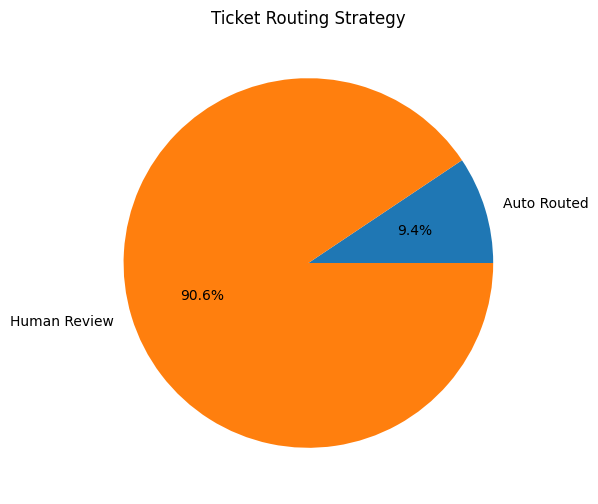

In [52]:
import matplotlib.pyplot as plt

sizes = [
    len(auto_tickets),
    len(manual_tickets)
]

labels = [
    "Auto Routed",
    "Human Review"
]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%"
)
plt.title("Ticket Routing Strategy")
plt.show()

In [53]:
results = pd.DataFrame({
    "Metric":[
        "Total Tickets",
        "Auto Routed Tickets",
        "Automation Rate (%)",
        "Auto Routing Accuracy (%)",
        "Labor Hours Saved"
    ],
    "Value":[
        len(preds),
        len(auto_tickets),
        round(len(auto_tickets)/len(preds)*100,2),
        round(auto_accuracy*100,2),
        round(hours_saved,2)
    ]
})

print(results)

                      Metric    Value
0              Total Tickets  2451.00
1        Auto Routed Tickets   230.00
2        Automation Rate (%)     9.38
3  Auto Routing Accuracy (%)    93.04
4          Labor Hours Saved   110.98


In [54]:
from sklearn.preprocessing import LabelEncoder

queue_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

df["queue_label"] = queue_encoder.fit_transform(df["queue"])
df["priority_label"] = priority_encoder.fit_transform(df["priority"])

In [55]:
import torch
import torch.nn as nn
from transformers import DistilBertModel

In [57]:
class MultiTaskDistilBERT(nn.Module):

    def __init__(
        self,
        n_queue,
        n_priority
    ):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )

        hidden = 768

        self.queue_head = nn.Linear(
            hidden,
            n_queue
        )

        self.priority_head = nn.Linear(
            hidden,
            n_priority
        )

        self.time_head = nn.Linear(
            hidden,
            1
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:,0]

        queue_logits = self.queue_head(cls)

        priority_logits = self.priority_head(cls)

        handle_time = self.time_head(cls)

        return (
            queue_logits,
            priority_logits,
            handle_time
        )

In [58]:
queue_loss = nn.CrossEntropyLoss()

priority_loss = nn.CrossEntropyLoss()

time_loss = nn.MSELoss()